# Creating a custom cardiac model

Finitewave lets you customize both the parameters and the equations of a cardiac model. In this tutorial, we compare action potentials in a small tissue strip and implement the same custom equations in two ways.

| Approach | Use it when… |
| :--- | :--- |
| **1. Change parameters** | An existing model has the equations you need. |
| **2. Implement `ComputationalModel`** | You want to manage state arrays and the reaction step yourself. |
| **3. Use model operations** | You want `CardiacModel` to allocate state and generate the backend kernel. |

**Before you start:** choose a notebook kernel with Finitewave, JAX, NumPy, Matplotlib, and the Bueno–Orovio and Aliev–Panfilov model plugins installed. Run the cells in order. The first simulation includes JAX compilation, so it may take longer than later runs.

The custom recovery equation below is an illustrative modification of Aliev–Panfilov; it is not a calibrated physiological model.


## Set up a shared experiment

Every run uses a **100 × 5** grid with spacing `dr=0.25` and time step `dt=0.01`. A voltage stimulus excites the first three rows at time zero, and a tracker records `u` at the center of the strip. Using the same geometry and stimulus makes the model comparisons easier to interpret.

These models use a **dimensionless voltage variable** `u`. We keep time in each model's native units: Bueno–Orovio uses milliseconds, while the Aliev–Panfilov examples below are shown in model time units.


In [25]:
from types import SimpleNamespace

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import finitewave as fw
from finitewave.simulation.model import CardiacModel, initialize_from_template_model_ops

plt.rcParams.update({
    "figure.figsize": (8, 3.8),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "lines.linewidth": 2,
    "legend.frameon": False,
})


In [26]:
def run_simulation(cardiac_model, t_max=200):
    """Stimulate a tissue strip and return time and central-cell voltage."""
    n, m = 100, 5
    tissue = fw.CardiacTissue([n, m], dr=0.25)

    stimuli = fw.StimSequence()
    stimuli.add_stim(fw.StimVoltageCoord(
        time=0, volt_value=1,
        x_min=0, x_max=3, y_min=0, y_max=m,
    ))

    tracker = fw.ActionPotentialTracker([n // 2, m // 2])
    trackers = fw.TrackerSequence()
    trackers.add_tracker(tracker)

    simulation = fw.CardiacSimulation(dt=0.01, t_max=t_max, backend="jax")
    simulation.cardiac_tissue = tissue
    simulation.stim_sequence = stimuli
    simulation.cardiac_model = cardiac_model
    simulation.tracker_sequence = trackers
    simulation.run(prog_bar=False)

    return np.asarray(tracker.tracking_times), np.asarray(tracker.output).reshape(-1)


def plot_traces(traces, title, time_label="Time (model units)"):
    """Plot a mapping of labels to (time, voltage) pairs."""
    fig, ax = plt.subplots(layout="constrained")
    for (label, (time, voltage)), style in zip(traces.items(), ["-", "--", ":"]):
        ax.plot(time, voltage, style, label=label)
    ax.set(title=title, xlabel=time_label, ylabel="Voltage u (dimensionless)")
    ax.grid(axis="y", alpha=0.2)
    ax.legend()
    plt.show()


## 1. Change an existing model's parameters

Use `set_parameters()` before the simulation to override defaults. The dictionary may contain only the parameters you want to change; all other values retain their defaults. For example, `model.set_parameters({"tau_fi": 0.045})` changes one time constant.

Here we retain the tutorial's full alternative Bueno–Orovio parameter set. It changes several properties together, including `D_model`, so differences in the recorded trace can reflect both local dynamics and wave propagation. Treat this as an example parameter set rather than a fit to a particular cell type.


In [28]:
model_parameters = {
    "D_model": 0.188,
    "tau_v1_m": 41.857,
    "tau_v2_m": 1150.0,
    "tau_v_p": 1.7,
    "tau_w1_m": 138.69,
    "tau_w2_m": 62.341,
    "tau_w_p": 177.41,
    "tau_fi": 0.045,
    "tau_o1": 410.0,
    "tau_o2": 64.914,
    "tau_so1": 115,
    "tau_so2": 6.5,
    "tau_s1": 11.457,
    "tau_s2": 53.902,
    "tau_si": 7.802,
    "tau_w_inf": 0.050,
    "theta_v": 0.35,
    "theta_w": 0.328,
    "theta_v_m": 0.126,
    "theta_o": 0.00005,
    "u_w_m": 0.055,
    "u_o": 0.0,
    "u_u": 0.9205,
    "u_so": 0.332,
    "u_s": 0.792,
    "k_w_m": 202.66,
    "k_so": 1.386,
    "k_s": 1.226,
    "w_inf_": 1.0,
}


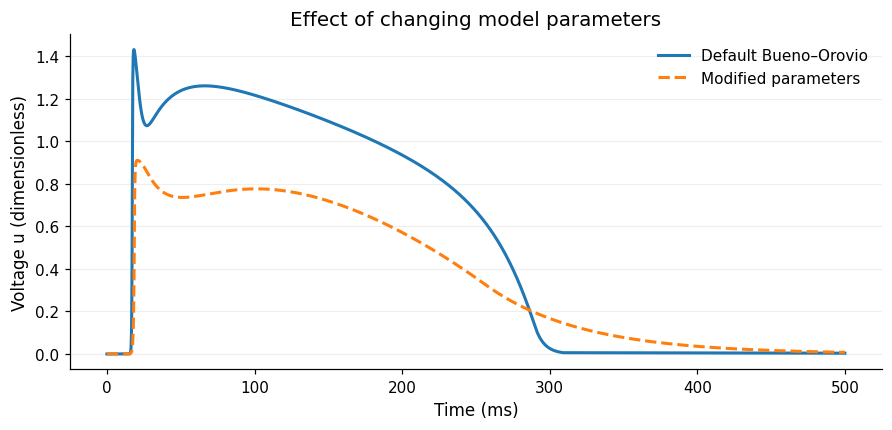

In [29]:
baseline_bo = fw.BuenoOrovio()
modified_bo = fw.BuenoOrovio()
modified_bo.set_parameters(model_parameters)

bo_traces = {
    "Default Bueno–Orovio": run_simulation(baseline_bo, t_max=500),
    "Modified parameters": run_simulation(modified_bo, t_max=500),
}
plot_traces(bo_traces, "Effect of changing model parameters", time_label="Time (ms)")


Compare the arrival time, plateau, and recovery of the two traces. The tracker is away from the stimulus, so the initial delay includes propagation through the tissue.

## 2. Implement a model directly with JAX

Our custom model has a voltage variable $u$ and a recovery variable $v$:

$$
\frac{\partial u}{\partial t}
= D\nabla^2 u + \underbrace{-ku(u-a)(u-1)-uv}_{\mathrm{rhs}},
\qquad
\frac{dv}{dt} = -(\varepsilon + \mu v)\,[v+ku(u-a-1)].
$$

The standard Aliev–Panfilov recovery rate contains $\varepsilon + \mu_1 v/(\mu_2+u)$. Here we replace it with $\varepsilon+\mu v$, a rate linear in $v$. The **full recovery equation remains nonlinear**.

The division of work is essential: `ionic_step()` returns the reaction term `rhs` and the updated recovery variable `v_new`. Finitewave's time integrator advances `u` using the reaction and diffusion terms. Advancing `u` inside `ionic_step()` would count the reaction twice.


In [30]:
def calc_dv(u, v, a, k, eps, mu):
    return -(eps + mu * v) * (v + k * u * (u - a - 1))


def ionic_step(dt, u, v, a, k, eps, mu):
    rhs = -k * u * (u - a) * (u - 1) - u * v
    v_new = v + dt * calc_dv(u, v, a, k, eps, mu)
    return rhs, v_new


# Keep the plain functions available for the template implementation below.
ionic_step_jax = jax.jit(ionic_step)


A direct `ComputationalModel` implementation supplies `initialize()` and `run()`. We store `_u`, `_rhs`, and `v` as compact, one-dimensional arrays with one entry per represented tissue point. Defaults belong in `__init__()` so calls to `set_parameters()` and `set_variables()` made before initialization are respected.

This implementation uses JAX arrays and is intended for the JAX experiment above. Its `u` property exposes the compact array; the template approach in the next section provides Finitewave's standard state access and array handling.


In [31]:
class AlievPanfilovLinear(fw.ComputationalModel):
    """Aliev–Panfilov variant with a recovery rate linear in v (JAX)."""

    def __init__(self):
        super().__init__()
        self.D_model = 1.0
        self.init_u = 0.0
        self.init_v = 0.0
        self.a = 0.1
        self.k = 8.0
        self.eps = 0.01
        self.mu = 0.01

    def initialize(self, simulation):
        self.simulation = simulation
        tissue = simulation.cardiac_tissue
        shape = tissue.tissue_indexes.shape
        self._u = jnp.full(shape, self.init_u, dtype=jnp.float32)
        self.v = jnp.full(shape, self.init_v, dtype=jnp.float32)
        self._rhs = jnp.zeros(shape, dtype=jnp.float32)
        self.tissue_indexes = jnp.asarray(tissue.tissue_indexes, dtype=jnp.int32)
        self.myo_indexes = jnp.asarray(tissue.myo_indexes, dtype=jnp.int32)

    @property
    def u(self):
        return self._u

    @u.setter
    def u(self, value):
        self._u = value

    def run(self):
        self._rhs, self.v = ionic_step_jax(
            self.simulation.dt, self._u, self.v,
            self.a, self.k, self.eps, self.mu,
        )

    def sync_backend(self):
        jax.block_until_ready((self._u, self._rhs, self.v))


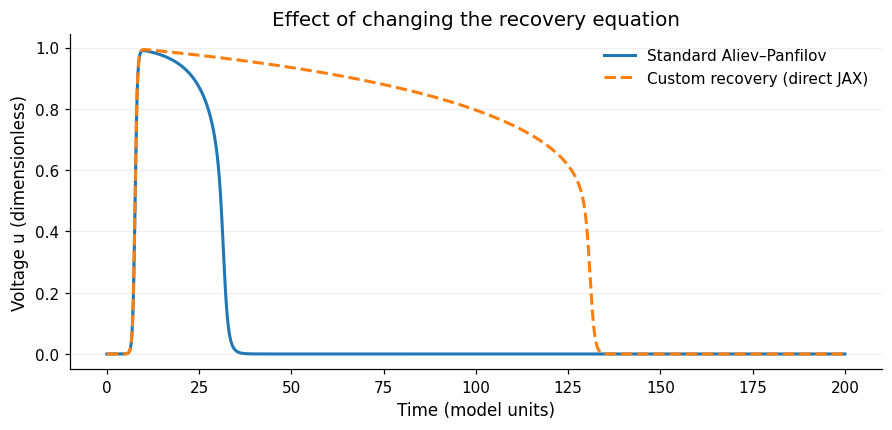

In [32]:
ap_reference = run_simulation(fw.AlievPanfilov())
ap_direct = run_simulation(AlievPanfilovLinear())

plot_traces({
    "Standard Aliev–Panfilov": ap_reference,
    "Custom recovery (direct JAX)": ap_direct,
}, "Effect of changing the recovery equation")


The two traces represent different equations and parameter sets, so they are not expected to match. Next, we implement the **same custom model** through the template interface and check that the two implementations agree.

## 3. Build the same model from operations

For most new equation sets, the template interface avoids writing array allocation and backend integration yourself. Supply an operations object and initialize a `CardiacModel` with `initialize_from_template_model_ops()`.

| Operation | What it supplies |
| :--- | :--- |
| `get_diffusion_coefficient()` | A dictionary containing `D_model`. |
| `get_variables()` | Initial state values, with `u` first. |
| `get_parameters()` | Named parameter defaults. |
| `ionic_step(dt, u, v, ...)` | `rhs`, followed by updated non-voltage states in variable order. |
| `calc_*()` helpers | Equation helpers used by `ionic_step()`. |

The kernel generator reads the function source. Keep operations as plain Python functions, expose equation helpers with a `calc_` prefix, and use named results such as `rhs` and `v_new` in a single return statement. The backend handles compilation.

A `SimpleNamespace` is enough for a notebook; a Python module can expose the same functions when you move the model into a package.


In [33]:
def get_diffusion_coefficient():
    return {"D_model": 1.0}


def get_variables():
    return {"u": 0.0, "v": 0.0}


def get_parameters():
    return {"a": 0.1, "k": 8.0, "eps": 0.01, "mu": 0.01}


# Reuse the exact equations from section 2, without JAX decorators.
ops = SimpleNamespace(
    get_diffusion_coefficient=get_diffusion_coefficient,
    get_variables=get_variables,
    get_parameters=get_parameters,
    ionic_step=ionic_step,
    calc_dv=calc_dv,
)


class AlievPanfilovTemplate(CardiacModel):
    """The same custom recovery model, using generated backend kernels."""

    def __init__(self):
        super().__init__()
        initialize_from_template_model_ops(self, ops)


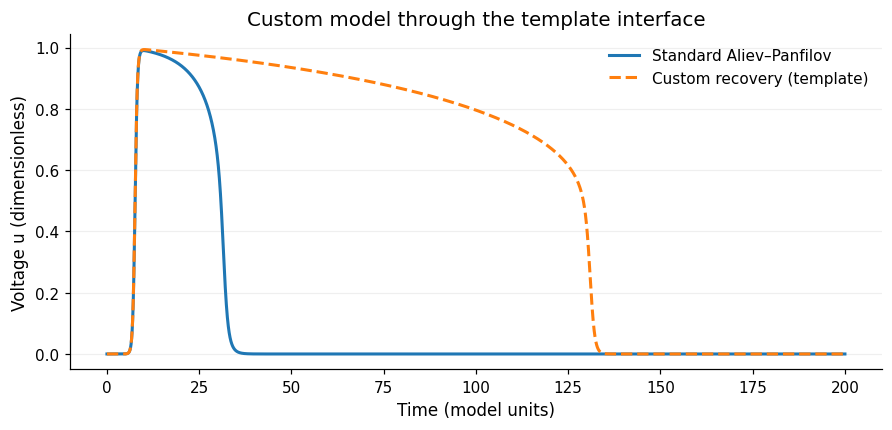

In [34]:
ap_template = run_simulation(AlievPanfilovTemplate())

plot_traces({
    "Standard Aliev–Panfilov": ap_reference,
    "Custom recovery (template)": ap_template,
}, "Custom model through the template interface")


### Check that the implementations agree

Compare every recorded sample from the direct and template implementations. We allow a small floating-point tolerance because JAX may compile the two paths differently. Agreement here checks the two implementations for this experiment; it does not establish time-step convergence or physiological validity.


In [35]:
direct_time, direct_u = ap_direct
template_time, template_u = ap_template

assert np.isfinite(direct_u).all() and np.isfinite(template_u).all()
np.testing.assert_allclose(direct_time, template_time, rtol=0, atol=1e-12)
np.testing.assert_allclose(direct_u, template_u, rtol=1e-4, atol=1e-5)
print(f"Maximum voltage difference: {np.max(np.abs(direct_u - template_u)):.2e}")


Maximum voltage difference: 1.79e-07


## Try your own variation

Create a fresh template model and change one parameter at a time to isolate its effect. Initial conditions can be set with `set_variables()` before running, for example `model.set_variables({"u": 0.0, "v": 0.0})`.


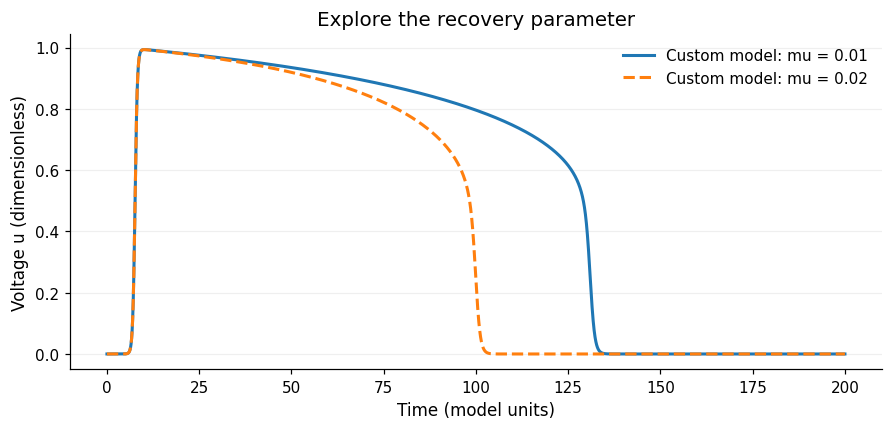

In [37]:
faster_recovery = AlievPanfilovTemplate()
faster_recovery.mu = 0.02  # Increase the recovery rate.

plot_traces({
    "Custom model: mu = 0.01": ap_template,
    "Custom model: mu = 0.02": run_simulation(faster_recovery),
}, "Explore the recovery parameter")


When extending the equations, keep the variable dictionary, step-function arguments, and returned states consistent. If you add a state `w`, initialize it in `get_variables()`, compute `w_new`, and return `rhs, v_new, w_new`.

For further experiments, adjust the stimulus location or record another cell. Recheck the time step when changing kinetics, diffusion, or grid spacing. See [Cardiac models](CardiacModels.ipynb) for built-in models and [Diffusion models](DiffusionModels.ipynb) for spatial coupling.
